In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
import numpy as np
import pandas as pd

from utils import validate, package_run_data, package_calib_data, circdist, circmedian
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel

#NP set random seed
np.random.seed(42)

az.style.use("arviz-docgrid")

## Loading data

In [5]:
experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07", "08" ,"09", "10", "11", "12", "14"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

In [6]:
# Allow negative angles
c_table, med, std, ctimetable = package_calib_data(do_clip=False)
r_table, (x, y, d, r, e) = package_run_data(med, std, do_clip=False)

Loading data: 100%|██████████| 312/312 [00:01<00:00, 305.82it/s]


## Err aginst ideal line

In [7]:
low_coherence_mask = r_table["coh"] == -1
high_coherence_mask = r_table["coh"] == 1

divided_attention_mask = r_table["att"] == -1
focused_attention_mask = r_table["att"] == 1

unexpected_mask = r_table["exp_al"] == 0
expected_mask = r_table["exp_al"] == 1

In [8]:
n_sub, n_sess, n_blocks, n_trials, n_ts = x.shape

In [9]:
f_r = r_table["f_resp"].values
f_t = r_table["t_calib"].values

In [173]:
def generate_line_coordinates(theta_deg, steps, geoms = False):
    # Convert angle to radians
    theta_rad = np.radians(theta_deg)
    
    # Calculate x, y at the circumference of the unit circle
    x_final = np.cos(theta_rad)
    y_final = np.sin(theta_rad)

    if geoms:
        # Generate evenly spaced points from (0,0) to (x_final, y_final)
        x_coords = np.geomspace(0, x_final, steps)
        y_coords = np.geomspace(0, y_final, steps)
    
    else:
        # Generate evenly spaced points from (0,0) to (x_final, y_final)
        x_coords = np.linspace(0, x_final, steps)
        y_coords = np.linspace(0, y_final, steps)
    
    return x_coords, y_coords

In [142]:
x_d = np.zeros(shape=(13* 4* 6* 120, 1000))
y_d = np.zeros(shape=(13* 4* 6* 120, 1000))
x_d[:] = np.nan
y_d[:] = np.nan

for idx in range(13* 4* 6* 120):
    step_size = f_r[idx] + 1
    x_t, y_t = generate_line_coordinates(f_t[idx], step_size - 250 + 1)
    x_d[idx, 250: step_size] = np.abs(x.reshape(-1,1000)[idx, 250:step_size] - x_t[1:])
    y_d[idx, 250: step_size] = np.abs(y.reshape(-1,1000)[idx, 250:step_size] - y_t[1:])


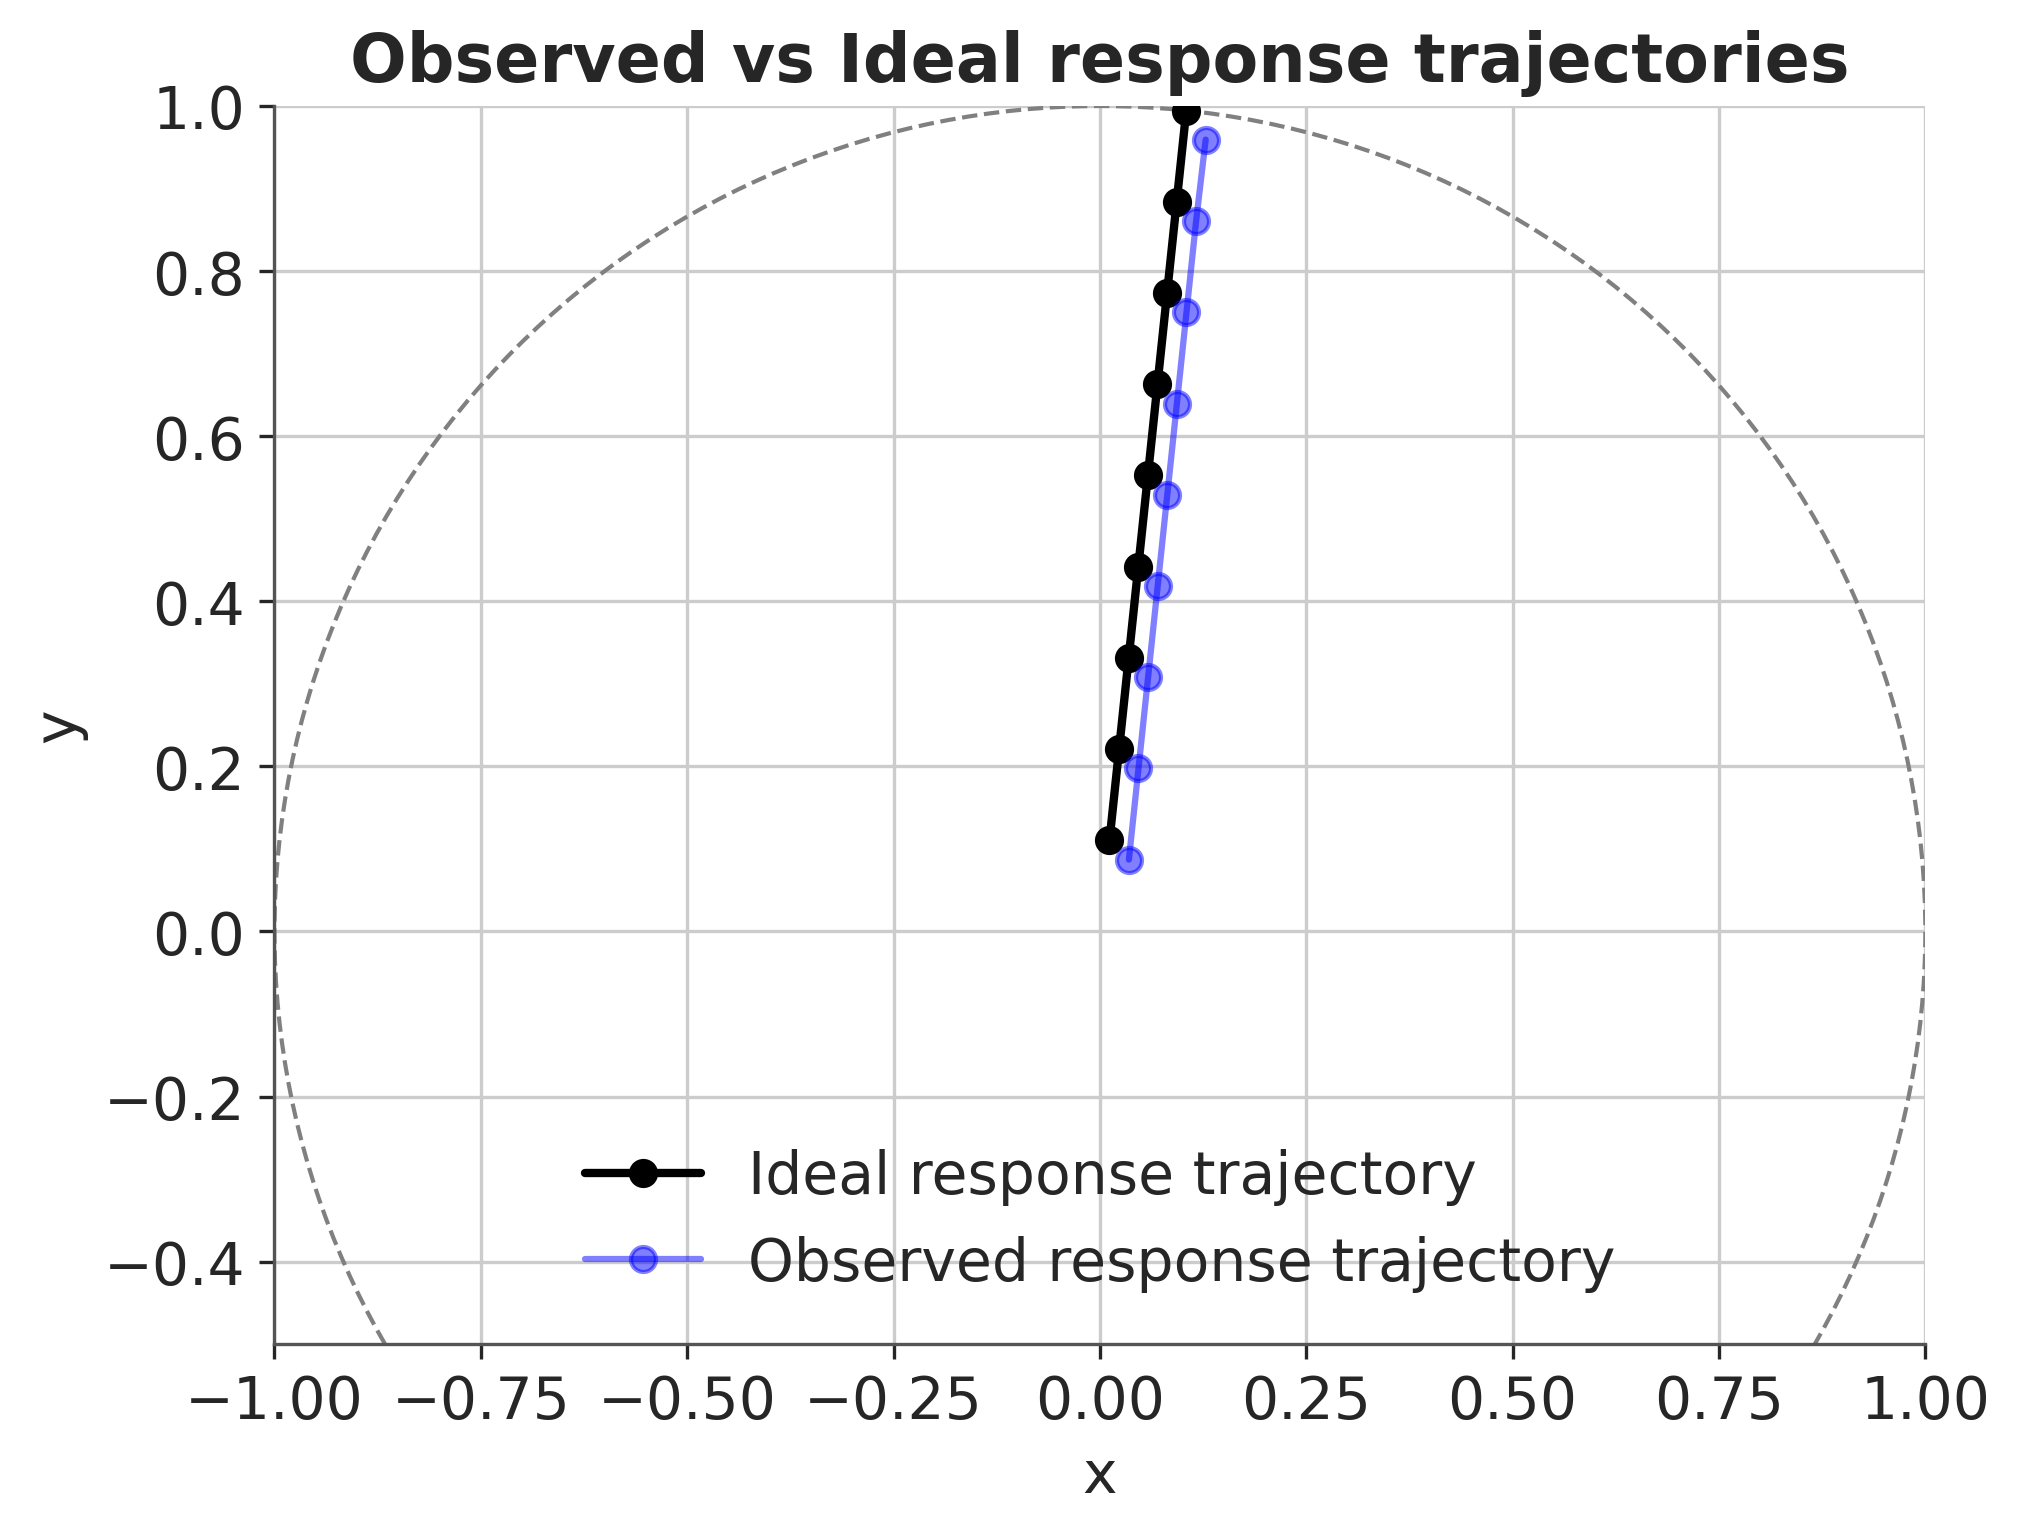

In [143]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# idx = 8015
idx = 8015

# plot the true line
x_t, y_t = generate_line_coordinates(f_t[idx], f_r[idx] - 250 + 2)
ax.plot(x_t[1:], y_t[1:], color="black", marker="o", linewidth=2, label="Ideal response trajectory")

# plot the observed line
# ax.plot(x_d[idx], y_d[idx], color="blue", marker="o", alpha=0.5)
ax.plot(x_d[idx], y_d[idx], color="blue", marker="o", alpha=0.5, label="Observed response trajectory")

# plot a circle of radius .5
circle = plt.Circle((0, 0), 1, color='gray', linestyle="--", fill=False)
ax.add_artist(circle)

ax.set_aspect("equal")
ax.set_title("Observed vs Ideal response trajectories")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_xlim(-1, 1)
ax.set_ylim(-0.5, 1)

plt.legend()

plt.show()

In [144]:
ed = np.sqrt(x_d**2 + y_d**2)

In [145]:
r_low = np.nanmean(ed[low_coherence_mask], axis=0)
r_high = np.nanmean(ed[high_coherence_mask], axis=0)

r_divided = np.nanmean(ed[divided_attention_mask], axis=0)
r_focused = np.nanmean(ed[focused_attention_mask], axis=0)

r_unexpected = np.nanmean(ed[unexpected_mask], axis=0)
r_expected = np.nanmean(ed[expected_mask], axis=0)

/tmp/ipykernel_59409/3038185096.py:1: RuntimeWarning: Mean of empty slice
  r_low = np.nanmean(ed[low_coherence_mask], axis=0)
/tmp/ipykernel_59409/3038185096.py:2: RuntimeWarning: Mean of empty slice
  r_high = np.nanmean(ed[high_coherence_mask], axis=0)
/tmp/ipykernel_59409/3038185096.py:4: RuntimeWarning: Mean of empty slice
  r_divided = np.nanmean(ed[divided_attention_mask], axis=0)
/tmp/ipykernel_59409/3038185096.py:5: RuntimeWarning: Mean of empty slice
  r_focused = np.nanmean(ed[focused_attention_mask], axis=0)
/tmp/ipykernel_59409/3038185096.py:7: RuntimeWarning: Mean of empty slice
  r_unexpected = np.nanmean(ed[unexpected_mask], axis=0)
/tmp/ipykernel_59409/3038185096.py:8: RuntimeWarning: Mean of empty slice
  r_expected = np.nanmean(ed[expected_mask], axis=0)


In [146]:
labels = ["Low Coherence", "High Coherence", "Divided Attention", "Focused Attention", "Unexpected", "Expected"]
colors = ["gray", "darkgray", "blue", "darkblue", "red", "darkred"]
linestyles = ["--", "-", "--", "-", "--", "-"]

xaxis = np.array(range(-250, 750, 1))*(1000/120)

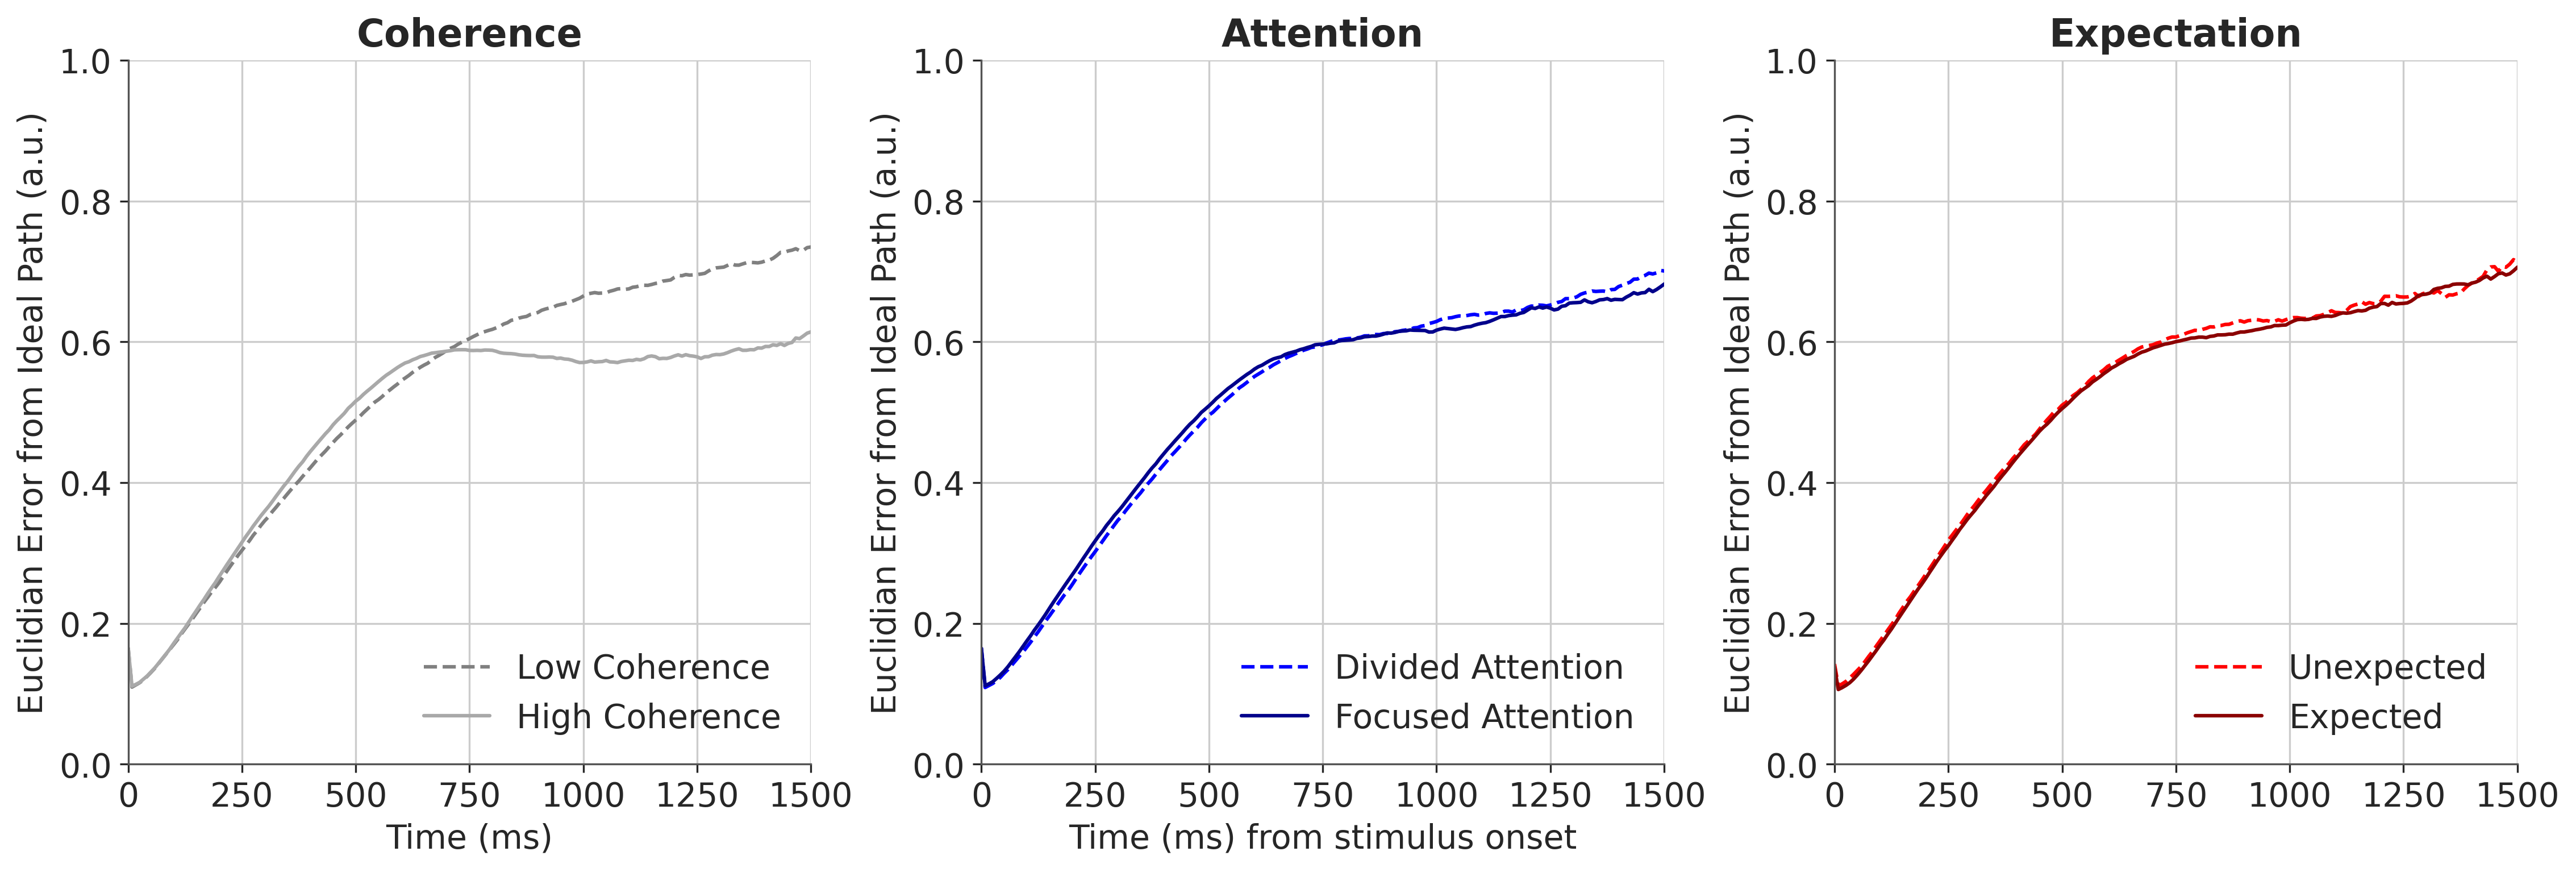

In [147]:
# 1, 3 plot with coh, att, and exp.

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# First subplot has coherence
# ax[0].plot(xaxis, np.log(r_low), label="Low Coherence", color="gray", linestyle="--")
# ax[0].plot(xaxis, np.log(r_high), label="High Coherence", color="darkgray")
ax[0].plot(xaxis, r_low, label="Low Coherence", color="gray", linestyle="--")
ax[0].plot(xaxis, r_high, label="High Coherence", color="darkgray")
ax[0].set_title("Coherence")
ax[0].set_xlabel("Time (ms)")

# Second subplot has attention
ax[1].plot(xaxis, r_divided, label="Divided Attention", color="blue", linestyle="--")
ax[1].plot(xaxis, r_focused, label="Focused Attention", color="darkblue")
ax[1].set_title("Attention")
ax[1].set_xlabel("Time (ms) from stimulus onset")

# Third subplot has expectation
# ax[2].plot(xaxis, np.log(r_unexpected), label="Unexpected", color="red", linestyle="--")
# ax[2].plot(xaxis, np.log(r_expected), label="Expected", color="darkred")
ax[2].plot(xaxis, r_unexpected, label="Unexpected", color="red", linestyle="--")
ax[2].plot(xaxis, r_expected, label="Expected", color="darkred")
ax[2].set_title("Expectation")

for a in ax.flatten():
    a.set_ylabel("Euclidian Error from Ideal Path (a.u.)")
    a.legend(loc="lower right")
    a.set_xlim(0, 1500)
    a.set_ylim(0, 1)

In [148]:
## This time wigh geomspace instead of linspace

x_d = np.zeros(shape=(13* 4* 6* 120, 1000))
y_d = np.zeros(shape=(13* 4* 6* 120, 1000))
x_d[:] = np.nan
y_d[:] = np.nan

for idx in range(13* 4* 6* 120):
    step_size = f_r[idx] + 1
    x_t, y_t = generate_line_coordinates(f_t[idx], step_size - 250 + 1, geoms=True)
    x_d[idx, 250: step_size] = np.abs(x.reshape(-1,1000)[idx, 250:step_size] - x_t[1:])
    y_d[idx, 250: step_size] = np.abs(y.reshape(-1,1000)[idx, 250:step_size] - y_t[1:])




## RRR QV estimation with SGD

In [33]:

# ---------------------------
# Example synthetic data setup
# ---------------------------

# Suppose we have I sessions
I = 200

# For each session, we have:
# T_i = number of trials in session i
# N_i = number of neurons in session i
T_list = [100] * I   # different number of trials per session
N_list = [100] * I   # different number of neurons per session

# Rank for the reduced rank regression
R = 2

# Generate some synthetic neural data and behavior
# In a real scenario, Xs and ds come from actual experiments
torch.manual_seed(0)
Xs = []
ds = []

V_true = torch.randn(R)
print(f"V = {V_true}")

for i in range(I):
    X_i = torch.randn(T_list[i], N_list[i])
    # True underlying U^i, V, and b^i (just for simulation)
    U_true = torch.randn(N_list[i], R)
    b_true = torch.randn(1)

    # Print the U^i, V, and b^i for each session
    # print(f"U^{i} = {U_true}")
    # print(f"b^{i} = {b_true}")
    
    # Generate behavior with a bit of noise
    d_i = X_i @ U_true @ V_true + b_true + 0.001 * torch.randn(T_list[i])
    Xs.append(X_i)
    ds.append(d_i)

V = tensor([ 1.5410, -0.2934])


In [34]:
# ---------------------------
# Model Parameters
# ---------------------------

# We'll create one shared V for all sessions
V = nn.Parameter(torch.randn(R))

# For each session, we create U^i and b^i
U_params = nn.ParameterList([nn.Parameter(torch.randn(N_list[i], R)) for i in range(I)])
b_params = nn.ParameterList([nn.Parameter(torch.zeros(1)) for _ in range(I)])

# ---------------------------
# Optimization Setup
# ---------------------------

learning_rate = 1e-2
optimizer = optim.Adam([V] + list(U_params) + list(b_params), lr=learning_rate)
criterion = nn.MSELoss()

# ---------------------------
# Training Loop
# ---------------------------
num_epochs = 2000
for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    loss = 0.0
    for i in range(I):
        # Model prediction for session i: d_hat^i = X^i U^i V + b^i
        # (T_i x N_i)(N_i x R)(R) -> T_i
        d_pred = Xs[i] @ U_params[i] @ V + b_params[i]
        
        # Compute loss for session i
        loss += criterion(d_pred, ds[i])
        
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 500 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 500/2000, Loss: 157.7759
Epoch 1000/2000, Loss: 26.1412
Epoch 1500/2000, Loss: 8.6158
Epoch 2000/2000, Loss: 3.7794


In [37]:
# ---------------------------
# After training
# ---------------------------
print("Optimization complete.")
print("Learned V:", V.data)
# for i in range(I):
#     print(f"Session {i+1}: U shape={U_params[i].shape}, b={b_params[i].item():.4f}")


Optimization complete.
Learned V: tensor([ 0.8369, -1.2804])


In [38]:
print("True V:", V_true)

True V: tensor([ 1.5410, -0.2934])


In [55]:
# Take data, transform it to the reduced rank space, and plot
# Do a single session for simplicity

# Get the first session
X = Xs[0]
d = ds[0]

# Get the learned U and b for the first session
U = U_params[0].data
b = b_params[0].data

# Transform the data to the reduced rank space
d_pred = (X @ U @ V + b).detach().numpy()


Text(0.5, 0, 'True d')

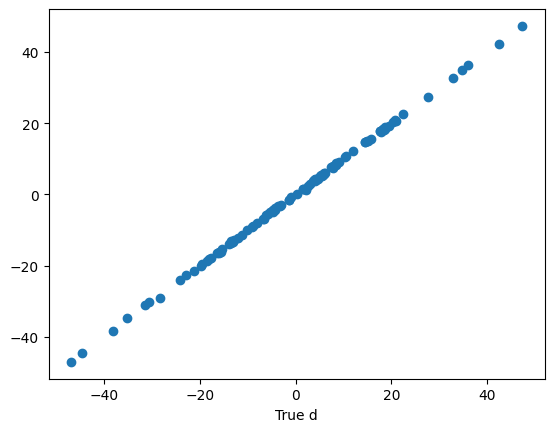

In [56]:
# Visualize only the 2d embedding space of the low rank model
import matplotlib.pyplot as plt
plt.scatter(d, d_pred)
plt.xlabel("True d")

In [54]:
b

tensor([-0.0826])

## PCA

In [11]:
# import pca
from sklearn.decomposition import PCA
import phate
import scprep

In [12]:
phate_operator = phate.PHATE(n_components = 2, n_jobs=-2)

In [13]:
x.shape, y.shape, d.shape, r.shape, e.shape

((13, 4, 6, 120, 1000),
 (13, 4, 6, 120, 1000),
 (13, 4, 6, 120, 1000),
 (13, 4, 6, 120, 1000),
 (13, 4, 6, 120, 1000))

In [21]:
pdata = np.stack([x, y, d, r, e], axis=-1)

In [32]:
df = pdata[:,:1,:,::20,191:430:8,:].reshape(-1, 5) #(191, 430)
# replace nan with 0
df = np.nan_to_num(df)
print(df.shape)

(14040, 5)


In [33]:
Y_phate = phate_operator.fit_transform(df)

Calculating PHATE...
  Running PHATE on 14040 observations and 5 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.20 seconds.
    Calculating affinities...


/home/nuttidalab/miniconda3/envs/ssm/lib/python3.9/site-packages/graphtools/graphs.py:290: RuntimeWarning: Detected zero distance between 73028 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    Calculated affinities in 0.26 seconds.
  Calculated graph and diffusion operator in 0.48 seconds.
  Calculating landmark operator...
    Calculating SVD...


/home/nuttidalab/miniconda3/envs/ssm/lib/python3.9/site-packages/graphtools/graphs.py:454: RuntimeWarning: overflow encountered in power
  K.data = np.exp(-1 * np.power(K.data, self.decay))


    Calculated SVD in 218.15 seconds.
    Calculating KMeans...
    Calculated KMeans in 12.28 seconds.
  Calculated landmark operator in 230.88 seconds.
  Calculating optimal t...
    Automatically selected t = 25
  Calculated optimal t in 55.71 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.33 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 3.25 seconds.
Calculated PHATE in 290.68 seconds.


In [61]:
c = r_table["exp_al"].values
c = np.nan_to_num(c)
c = c.reshape((13, 4, 6, 120))
c = c[:,:1,:,::20]
c = np.tile(c, 1000)
c = c.reshape(13, 1, 6, 6, 1000)
c = c.reshape(-1, 1000)[:, 191:430:8]
c = c.reshape(-1)
# c = c.repeat(1000, axis=3)
c.shape

(14040,)

In [36]:
Y_phate.shape

(14040, 2)

In [ ]:
scprep.plot.scatter2d(Y_phate, c=c, figsize=(4,4), cmap="Spectral", ticks=False, label_prefix="PHATE")

In [34]:
# scprep.plot.scatter2d(Y_phate, c=sample_labels, figsize=(12,8), cmap="Spectral",
#                       ticks=False, label_prefix="PHATE")